# Host Performance Analysis.

### Importing Libraries(Toolkit).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Loading & Inspecting Dataset.

In [2]:
df = pd.read_csv('Listings.csv', encoding='latin1')
df.head()

C:\Users\abdal\AppData\Local\Temp\ipykernel_21420\3073548369.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Listings.csv', encoding='latin1')


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [4]:
df.shape

(279712, 33)

In [5]:
df.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [6]:
df = df[['host_id','name','host_since','host_location','host_is_superhost','host_total_listings_count',
         'host_has_profile_pic','host_identity_verified','review_scores_rating',
         'price','city','room_type']]


In [7]:
df

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,53,Paris,Entire place
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,120,Paris,Entire place
2,19252768,"Lovely apartment with Terrace, 60m2",2014-07-31,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,89,Paris,Entire place
3,10668311,Cosy studio (close to Eiffel tower),2013-12-17,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,58,Paris,Entire place
4,24837558,Close to Eiffel Tower - Beautiful flat : 2 rooms,2014-12-14,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,60,Paris,Entire place
...,...,...,...,...,...,...,...,...,...,...,...,...
279707,31161181,Appartement T2 neuf prÃÂ¨s du tram T3a Porte ...,2015-04-13,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,120,Paris,Entire place
279708,10294858,Cozy Studio in Montmartre,2013-11-27,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,60,Paris,Entire place
279709,2238502,Nice and cosy mini-appartement in Paris,2012-04-27,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,50,Paris,Entire place
279710,38633695,Charming apartment near Rue Saint Maur / Oberk...,2015-07-16,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,105,Paris,Entire place


In [8]:
df['city'].value_counts()

city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64

In [9]:
host_paris = df[df['city'] == 'Paris' ]

In [10]:
host_paris

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,53,Paris,Entire place
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,120,Paris,Entire place
2,19252768,"Lovely apartment with Terrace, 60m2",2014-07-31,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,89,Paris,Entire place
3,10668311,Cosy studio (close to Eiffel tower),2013-12-17,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,58,Paris,Entire place
4,24837558,Close to Eiffel Tower - Beautiful flat : 2 rooms,2014-12-14,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,60,Paris,Entire place
...,...,...,...,...,...,...,...,...,...,...,...,...
279707,31161181,Appartement T2 neuf prÃÂ¨s du tram T3a Porte ...,2015-04-13,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,120,Paris,Entire place
279708,10294858,Cozy Studio in Montmartre,2013-11-27,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,60,Paris,Entire place
279709,2238502,Nice and cosy mini-appartement in Paris,2012-04-27,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,50,Paris,Entire place
279710,38633695,Charming apartment near Rue Saint Maur / Oberk...,2015-07-16,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,105,Paris,Entire place


In [11]:
host_paris.shape

(64690, 12)

In [12]:
host_paris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_id                    64690 non-null  int64  
 1   name                       64627 non-null  object 
 2   host_since                 64657 non-null  object 
 3   host_location              64522 non-null  object 
 4   host_is_superhost          64657 non-null  object 
 5   host_total_listings_count  64657 non-null  float64
 6   host_has_profile_pic       64657 non-null  object 
 7   host_identity_verified     64657 non-null  object 
 8   review_scores_rating       48036 non-null  float64
 9   price                      64690 non-null  int64  
 10  city                       64690 non-null  object 
 11  room_type                  64690 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 6.4+ MB


In [13]:
host_paris[['host_total_listings_count','review_scores_rating','price']].describe().round(2)

,host_total_listings_count,review_scores_rating,price
count,64657.00,48036.00,64690.00
mean,11.74,93.06,113.10
std,71.33,8.94,214.43
min,0.00,20.00,0.00
25%,1.00,90.00,59.00
50%,1.00,95.00,80.00
75%,2.00,100.00,120.00
max,1105.00,100.00,12000.00


In [14]:
from ydata_profiling import ProfileReport
ProfileReport(host_paris)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:01<00:00,  9.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Data Preprocessing.
- Missing Values.
- Duplicated Records.
- Invalid Values.
- Outliers.
- Types of Columns.
- Convert Boolean Columns to Upper Case.

In [15]:
host_paris.head(2)

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",f,1.0,t,f,100.0,53,Paris,Entire place
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",f,1.0,t,t,100.0,120,Paris,Entire place


In [16]:
host_paris.isna().sum()

host_id                          0
name                            63
host_since                      33
host_location                  168
host_is_superhost               33
host_total_listings_count       33
host_has_profile_pic            33
host_identity_verified          33
review_scores_rating         16654
price                            0
city                             0
room_type                        0
dtype: int64

In [17]:
host_paris.dropna(inplace= True)

C:\Users\abdal\AppData\Local\Temp\ipykernel_21420\814879656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  host_paris.dropna(inplace= True)


In [18]:
host_paris.isna().sum()


host_id                      0
name                         0
host_since                   0
host_location                0
host_is_superhost            0
host_total_listings_count    0
host_has_profile_pic         0
host_identity_verified       0
review_scores_rating         0
price                        0
city                         0
room_type                    0
dtype: int64

In [19]:
host_paris.shape

(47913, 12)

In [20]:
# Invalid Values.
host_paris[['price' ,'host_total_listings_count' ]].describe().round(2)

,price,host_total_listings_count
count,47913.00,47913.00
mean,107.34,9.23
std,195.29,57.93
min,8.00,0.00
25%,58.00,1.00
50%,80.00,1.00
75%,115.00,2.00
max,12000.00,1105.00


In [21]:
host_paris = host_paris[host_paris['host_total_listings_count'] != 0]

In [22]:
host_paris[['price' ,'host_total_listings_count' ]].describe().round(2)

,price,host_total_listings_count
count,42426.00,42426.00
mean,109.09,10.42
std,205.64,61.46
min,8.00,1.00
25%,58.00,1.00
50%,80.00,1.00
75%,117.00,2.00
max,12000.00,1105.00


<Axes: >

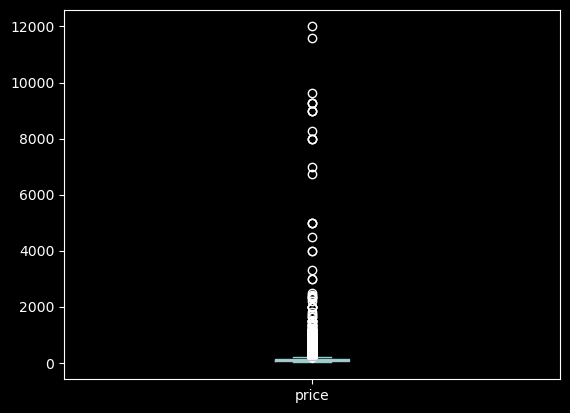

In [23]:
# Outliers

host_paris['price'].plot(kind='box')

In [24]:
q1 = host_paris['price'].quantile(0.25)
q3 = host_paris['price'].quantile(0.75)

IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

host_paris = host_paris[ (host_paris['price'] >= lower ) & (host_paris['price']) <= upper ]


In [25]:
q1 = host_paris['host_total_listings_count'].quantile(0.25)
q3 = host_paris['host_total_listings_count'].quantile(0.75)

IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

host_paris = host_paris[ (host_paris['host_total_listings_count'] >= lower ) & (host_paris['host_total_listings_count']) <= upper ]


In [26]:
host_paris.shape

(42426, 12)

In [27]:
host_paris['host_since'].info()

<class 'pandas.core.series.Series'>
Index: 42426 entries, 0 to 279711
Series name: host_since
Non-Null Count  Dtype 
--------------  ----- 
42426 non-null  object
dtypes: object(1)
memory usage: 662.9+ KB


In [28]:
host_paris['host_since'] = pd.to_datetime(host_paris['host_since'])

In [29]:
host_paris['year_host_join'] = host_paris['host_since'].dt.year

In [30]:
host_paris['host_experience_years'] = datetime.now().year - host_paris['year_host_join']

In [31]:
host_paris['host_total_listings_count'] = host_paris['host_total_listings_count'].astype('int')

In [32]:
host_paris['host_is_superhost'].value_counts()

host_is_superhost
f    35465
t     6961
Name: count, dtype: int64

In [33]:
host_paris['host_is_superhost'] = host_paris['host_is_superhost'].str.upper()
host_paris['host_has_profile_pic'] = host_paris['host_has_profile_pic'].str.upper()
host_paris['host_identity_verified'] = host_paris['host_identity_verified'].str.upper()

In [34]:
host_paris['room_type'] = host_paris['room_type'].str.title()

In [35]:
host_paris.head()

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type,year_host_join,host_experience_years
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",F,1,T,F,100.0,53,Paris,Entire Place,2011,14
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",F,1,T,T,100.0,120,Paris,Entire Place,2013,12
2,19252768,"Lovely apartment with Terrace, 60m2",2014-07-31,"Paris, Ile-de-France, France",F,1,T,F,100.0,89,Paris,Entire Place,2014,11
3,10668311,Cosy studio (close to Eiffel tower),2013-12-17,"Paris, Ile-de-France, France",F,1,T,T,100.0,58,Paris,Entire Place,2013,12
4,24837558,Close to Eiffel Tower - Beautiful flat : 2 rooms,2014-12-14,"Paris, Ile-de-France, France",F,1,T,F,100.0,60,Paris,Entire Place,2014,11


## Exploratory Data Analysis(EDA).
- Bi-variant Analysis.
- Multi-variant Analysis.

In [36]:
host_paris.head(2)

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type,year_host_join,host_experience_years
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",F,1,T,F,100.0,53,Paris,Entire Place,2011,14
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",F,1,T,T,100.0,120,Paris,Entire Place,2013,12


<Axes: xlabel='host_is_superhost'>

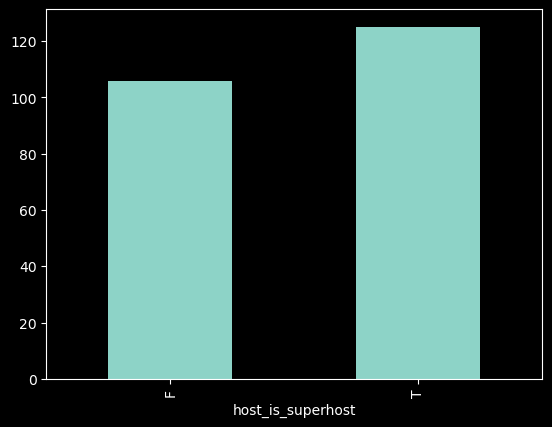

In [37]:
host_paris.groupby('host_is_superhost')['price'].mean().plot(kind= 'bar')

<Axes: xlabel='host_is_superhost'>

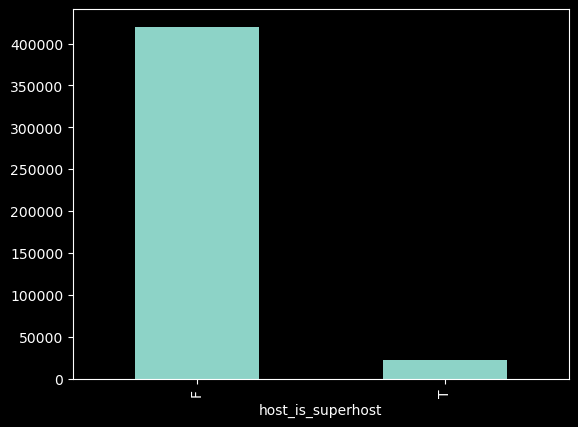

In [38]:
host_paris.groupby('host_is_superhost')['host_total_listings_count'].sum().plot(kind = 'bar')

<Axes: xlabel='host_is_superhost'>

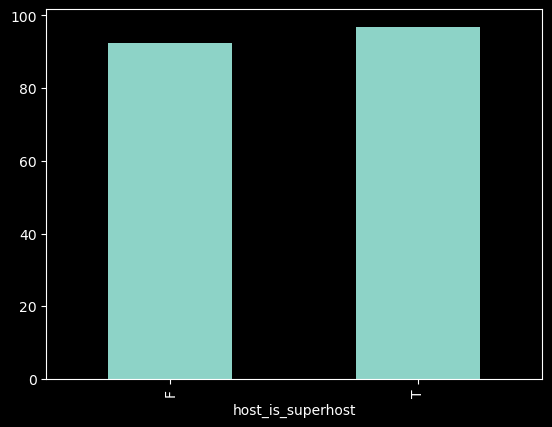

In [39]:
host_paris.groupby('host_is_superhost')['review_scores_rating'].mean().plot(kind = 'bar')


In [40]:
host_paris.groupby(['host_is_superhost', 'host_identity_verified']).size()

host_is_superhost  host_identity_verified
F                  F                          7267
                   T                         28198
T                  F                           663
                   T                          6298
dtype: int64

In [41]:
host_paris.head(3)

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type,year_host_join,host_experience_years
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",F,1,T,F,100.0,53,Paris,Entire Place,2011,14
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",F,1,T,T,100.0,120,Paris,Entire Place,2013,12
2,19252768,"Lovely apartment with Terrace, 60m2",2014-07-31,"Paris, Ile-de-France, France",F,1,T,F,100.0,89,Paris,Entire Place,2014,11


In [42]:
host_paris.groupby('host_has_profile_pic')['review_scores_rating'].mean().round(2)

host_has_profile_pic
F    91.43
T    93.03
Name: review_scores_rating, dtype: float64

In [43]:
host_paris.groupby('host_identity_verified')[['review_scores_rating', 'price']].mean().round(2)

,review_scores_rating,price
host_identity_verified,,
F,92.26,94.48
T,93.21,112.45


In [44]:
host_paris.groupby(['host_identity_verified' , 'host_is_superhost'])['host_experience_years'].mean().round()

host_identity_verified  host_is_superhost
F                       F                     9.0
                        T                     9.0
T                       F                    10.0
                        T                    10.0
Name: host_experience_years, dtype: float64

In [45]:
host_paris.head()

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type,year_host_join,host_experience_years
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",F,1,T,F,100.0,53,Paris,Entire Place,2011,14
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",F,1,T,T,100.0,120,Paris,Entire Place,2013,12
2,19252768,"Lovely apartment with Terrace, 60m2",2014-07-31,"Paris, Ile-de-France, France",F,1,T,F,100.0,89,Paris,Entire Place,2014,11
3,10668311,Cosy studio (close to Eiffel tower),2013-12-17,"Paris, Ile-de-France, France",F,1,T,T,100.0,58,Paris,Entire Place,2013,12
4,24837558,Close to Eiffel Tower - Beautiful flat : 2 rooms,2014-12-14,"Paris, Ile-de-France, France",F,1,T,F,100.0,60,Paris,Entire Place,2014,11


Text(0.5, 1.0, 'Average Price for each year host join')

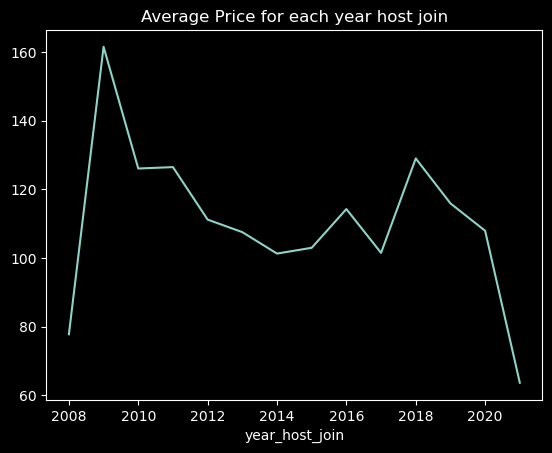

In [46]:
host_paris.groupby('year_host_join')['price'].mean().plot()
plt.title('Average Price for each year host join')

Text(0.5, 1.0, 'Sum of Price for each year host join')

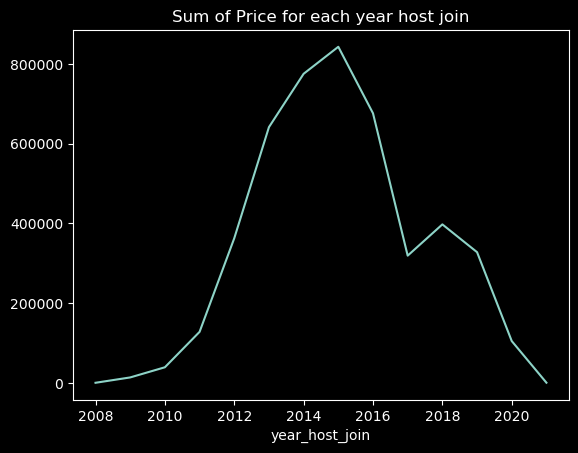

In [47]:
host_paris.groupby('year_host_join')['price'].sum().plot()
plt.title('Sum of Price for each year host join')

Text(0.5, 1.0, 'Total Number of host for each host join year')

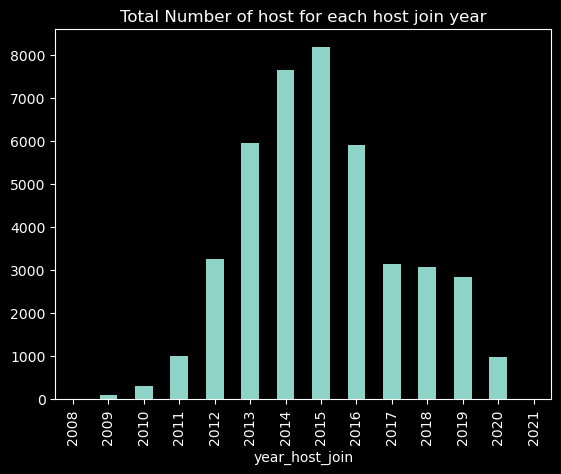

In [48]:
host_paris.groupby('year_host_join')['host_id'].count().plot(kind='bar')
plt.title('Total Number of host for each host join year')

<Axes: xlabel='year_host_join'>

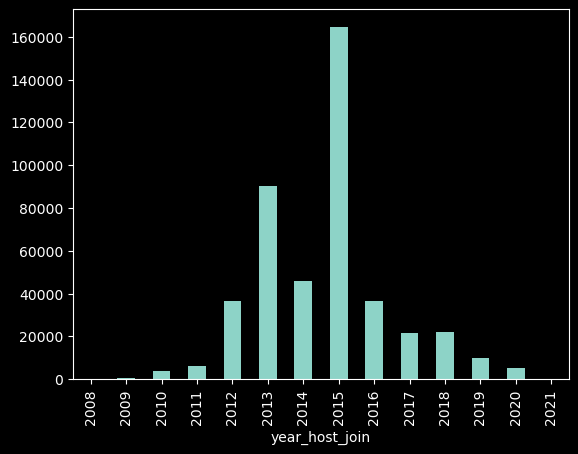

In [49]:
host_paris.groupby('year_host_join')['host_total_listings_count'].sum().plot(kind = 'bar')

Text(0.5, 1.0, 'total price for each room type')

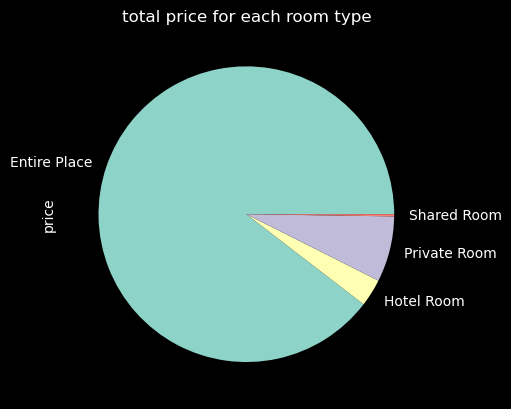

In [50]:
host_paris.groupby('room_type')['price'].sum().plot(kind='pie')
plt.title('total price for each room type')

### Save the Cleaned Dataset.

In [51]:
host_paris.to_csv('Listings_Cleaned.csv', index= False)

In [52]:
host_paris.head()

,host_id,name,host_since,host_location,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,review_scores_rating,price,city,room_type,year_host_join,host_experience_years
0,1466919,"Beautiful Flat in le Village Montmartre, Paris",2011-12-03,"Paris, Ile-de-France, France",F,1,T,F,100.0,53,Paris,Entire Place,2011,14
1,10328771,39 mÃÂ² Paris (Sacre CÃ âur),2013-11-29,"Paris, Ile-de-France, France",F,1,T,T,100.0,120,Paris,Entire Place,2013,12
2,19252768,"Lovely apartment with Terrace, 60m2",2014-07-31,"Paris, Ile-de-France, France",F,1,T,F,100.0,89,Paris,Entire Place,2014,11
3,10668311,Cosy studio (close to Eiffel tower),2013-12-17,"Paris, Ile-de-France, France",F,1,T,T,100.0,58,Paris,Entire Place,2013,12
4,24837558,Close to Eiffel Tower - Beautiful flat : 2 rooms,2014-12-14,"Paris, Ile-de-France, France",F,1,T,F,100.0,60,Paris,Entire Place,2014,11
